# **Digital Assignment - 3 : Predictive Analytics**


## **Machine Learning–Based Fraud Propensity Analysis for Insurance Claims**

**Name - Aditya Singh , Reg. No. - 23BCE1293**


**Name - Sattwik Sarkar , Reg. No. - 23BCE1297**

**Task**

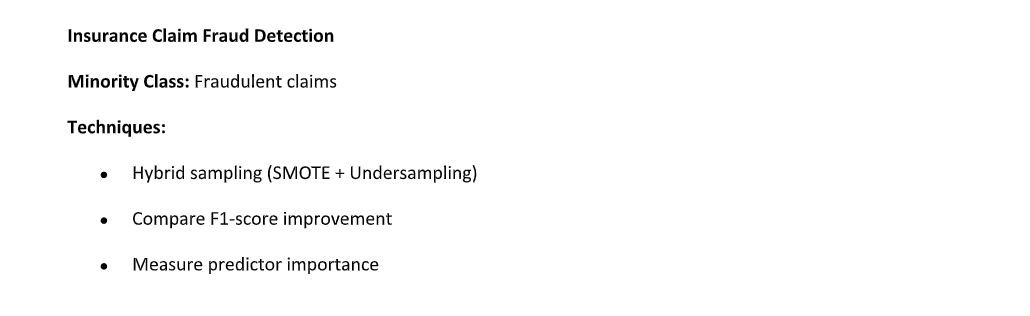

**Install Dependencies**

In [177]:
!pip install imbalanced-learn xgboost --quiet

**Import Libraries**

In [178]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.ensemble import BalancedRandomForestClassifier

from sklearn.metrics import *
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

**Load Dataset**

In [179]:
df = pd.read_csv("insurance_claims.csv")
df['fraud_reported'] = df['fraud_reported'].map({'Y':1, 'N':0})

## **1. Data Predictors and Target Identification**

In [180]:
import pandas as pd
target_column = 'fraud_reported'
y = df[target_column]
X = df.drop(columns=[target_column])
columns_to_drop = ['policy_number', 'incident_date', 'insured_zip']

existing_cols_to_drop = [col for col in columns_to_drop if col in X.columns]
if existing_cols_to_drop:
    X = X.drop(columns=existing_cols_to_drop)
print("--- Feature & Target Names ---")
print(f"Target Name (y): '{y.name}'\n")
print(f"Predictor Names (X):\n{X.columns.tolist()}\n")

print("--- Data Predictors & Target ---")
print(f"Shape of Predictors (X): {X.shape} -> ({X.shape[0]} rows, {X.shape[1]} features)")
print(f"Shape of Target (y): {y.shape} -> ({y.shape[0]} rows)\n")

display(X.head(3))

--- Feature & Target Names ---
Target Name (y): 'fraud_reported'

Predictor Names (X):
['months_as_customer', 'age', 'policy_bind_date', 'policy_state', 'policy_csl', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'capital-gains', 'capital-loss', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'incident_location', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'property_damage', 'bodily_injuries', 'witnesses', 'police_report_available', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make', 'auto_model', 'auto_year']

--- Data Predictors & Target ---
Shape of Predictors (X): (1000, 35) -> (1000 rows, 35 features)
Shape of Target (y): (1000,) -> (1000 rows)



,months_as_customer,age,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_sex,insured_education_level,...,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year
0,328,48,2014-10-17,OH,250/500,1000,1406.91,0,MALE,MD,...,1,2,YES,71610,6510,13020,52080,Saab,92x,2004
1,228,42,2006-06-27,IN,250/500,2000,1197.22,5000000,MALE,MD,...,0,0,?,5070,780,780,3510,Mercedes,E400,2007
2,134,29,2000-09-06,OH,100/300,2000,1413.14,5000000,FEMALE,PhD,...,2,3,NO,34650,7700,3850,23100,Dodge,RAM,2007


#2. **Class Distribution Visualization**

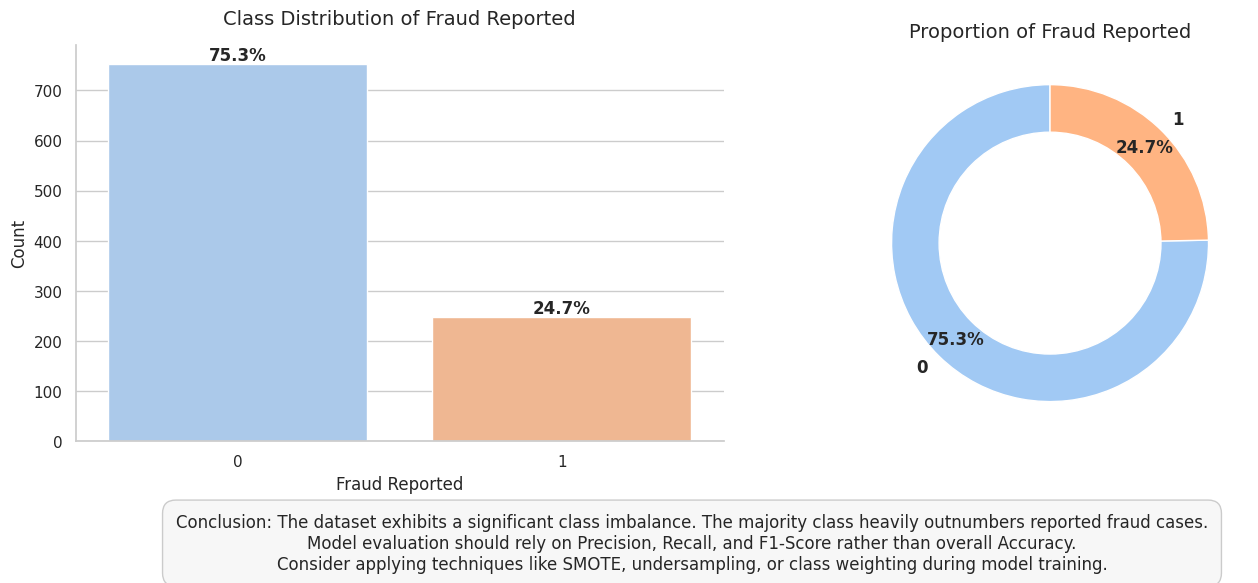

In [182]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Plot 1: Annotated Bar Chart (Left Side: axes[0])
sns.countplot(x='fraud_reported', data=df, palette='pastel', ax=axes[0], hue='fraud_reported', legend=False)
axes[0].set_title("Class Distribution of Fraud Reported", pad=15, fontsize=14)
axes[0].set_ylabel("Count", fontsize=12)
axes[0].set_xlabel("Fraud Reported", fontsize=12)

total = len(df)
for p in axes[0].patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = height
    axes[0].annotate(percentage, (x, y), ha='center', va='bottom',
                     fontweight='bold', fontsize=12)
sns.despine(ax=axes[0])

# Plot 2: Donut Chart (Right Side: axes[1])
counts = df['fraud_reported'].value_counts()

axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('pastel')[0:2], pctdistance=0.85,
            textprops={'fontsize': 12, 'weight': 'bold'})
centre_circle = plt.Circle((0,0), 0.70, fc='white')
axes[1].add_artist(centre_circle)
axes[1].set_title("Proportion of Fraud Reported", fontsize=14)

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
conclusion_text = (
    "Conclusion: The dataset exhibits a significant class imbalance. The majority class heavily outnumbers reported fraud cases.\n"
    "Model evaluation should rely on Precision, Recall, and F1-Score rather than overall Accuracy.\n"
    "Consider applying techniques like SMOTE, undersampling, or class weighting during model training."
)
fig.text(0.5, 0.08, conclusion_text, ha='center', va='center', fontsize=12,
         bbox=dict(boxstyle='round,pad=0.8', facecolor='whitesmoke', edgecolor='silver', alpha=0.8))

plt.show()

# **3. Data Preprocessing & 4. Data Transformation**


**Data Cleaning , Handling Noise**

In [183]:
df = df.drop(columns=['policy_number'], errors='ignore')
df = df.replace('?', np.nan)
df = df.ffill()

**Feature Engineering ( Dates & Financials )**

In [184]:
df['policy_bind_date'] = pd.to_datetime(df['policy_bind_date'])
df['incident_date'] = pd.to_datetime(df['incident_date'])

df['tenure_days'] = (df['incident_date'] - df['policy_bind_date']).dt.days
df['vehicle_age'] = df['incident_date'].dt.year - df['auto_year']
df['claim_ratio'] = df['total_claim_amount'] / (df['policy_annual_premium'] + 1)
df['net_capital'] = df['capital-gains'] + df['capital-loss']

# Claim proportions
df['vehicle_claim_prop'] = df['vehicle_claim'] / (df['total_claim_amount'] + 1)
df['injury_claim_prop'] = df['injury_claim'] / (df['total_claim_amount'] + 1)
df['property_claim_prop'] = df['property_claim'] / (df['total_claim_amount'] + 1)

**Feature Engineering (Behavior & Binning)**

In [185]:
df['is_out_of_state'] = (df['policy_state'] != df['incident_state']).astype(int)

bins = [-1, 5, 11, 16, 20, 24]
labels = ['Night', 'Morning', 'Afternoon', 'Evening', 'Late Night']
df['incident_time_of_day'] = pd.cut(df['incident_hour_of_the_day'], bins=bins, labels=labels)

**Drops High Cardinality & Redundant Column**

In [186]:
cols_to_drop = [
    'policy_bind_date', 'incident_date',
    'insured_zip', 'incident_location',
    'incident_hour_of_the_day',
    '_c39'
]
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns], errors='ignore')

**Split Feature**

In [187]:
X = df.drop(columns=['fraud_reported'])
y = df['fraud_reported']

**Preprocessing using Column Transformer ( Standard Scaler + OneHotEncoder)**

In [188]:
cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(include=['int64','float64']).columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

## **6.Data Splitting**

***Train-Test Split***

In [189]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (800, 41)
Test Shape: (200, 41)


**Cross Validation and Bias Variance Tradeoff**

In [190]:
from sklearn.model_selection import cross_val_score

base_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier())
])

cv_scores = cross_val_score(base_pipe, X_train, y_train, cv=5, scoring='f1')

print("Cross-validation F1 scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())

Cross-validation F1 scores: [0.26415094 0.37037037 0.45454545 0.34615385 0.34482759]
Mean CV F1: 0.3560096401345588


##**7. Model Training - Validation - Testing**

**Models**

In [191]:
models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(n_estimators=100),
    "XGBoost": XGBClassifier(eval_metric='logloss'),
    "BalancedRF": BalancedRandomForestClassifier(n_estimators=100)
}

***Model Training Function Defined***

In [192]:
def train_and_evaluate(model, name):
    model.fit(X_train, y_train)   # Training

    y_pred = model.predict(X_test)   # Testing
    y_prob = model.predict_proba(X_test)[:,1]

    print(f"\n{name} Results:")
    print(classification_report(y_test, y_pred))

    return y_pred, y_prob

##**8.Baseline Model (Without Balancing) - Logistic Regression**

In [193]:
baseline_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

y_pred_base, y_prob_base = train_and_evaluate(baseline_model, "Baseline Logistic")


Baseline Logistic Results:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       151
           1       0.58      0.45      0.51        49

    accuracy                           0.79       200
   macro avg       0.71      0.67      0.68       200
weighted avg       0.77      0.79      0.78       200



In [225]:
from sklearn.metrics import f1_score

f1_baseline = f1_score(y_test, y_pred_base)

print("Baseline F1:", round(f1_baseline, 3))

Baseline F1: 0.506


> Observation :

*Severe Class Imbalance: The dataset heavily favors Class 0 (151 instances) over Class 1 (49 instances).*

*Minority  Class Failure: Because of this imbalance, the model is highly biased. It accurately identifies the majority class but misses over half (55%) of the minority Class 1 instances.*

# **Applying Imbalance Remedies && Performnace Evaluation**

**Applying SMOTETomek and Class Distribution Comparison**

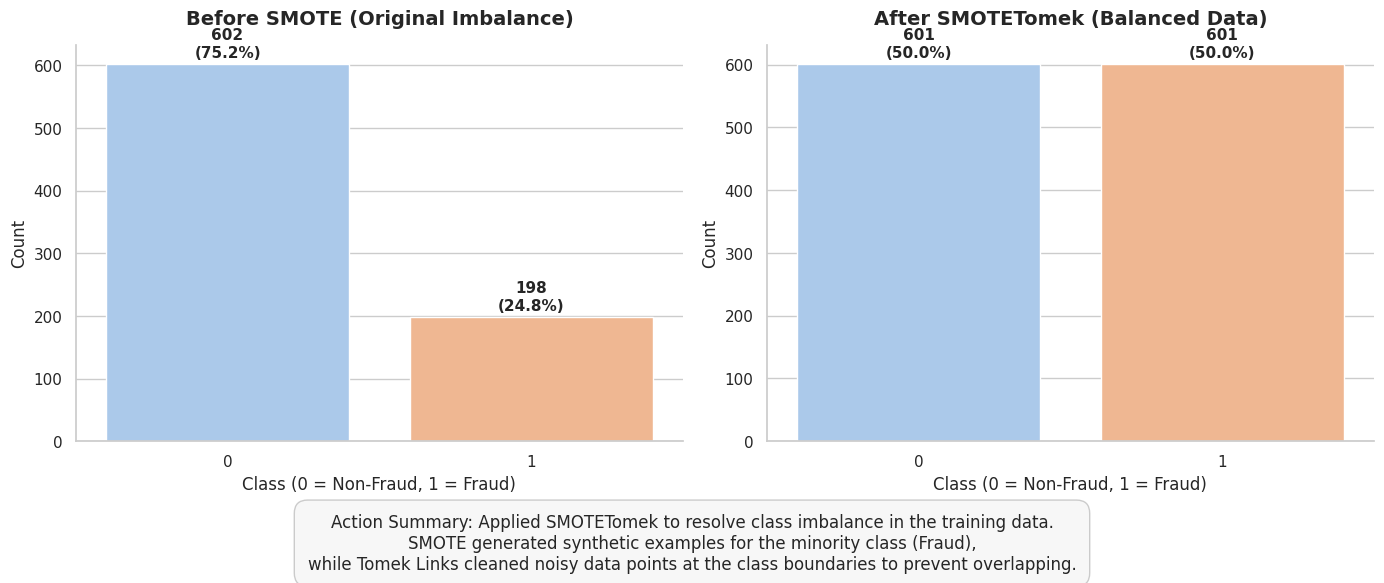


--- Data Distribution Summary ---
BEFORE Resampling:
fraud_reported
0    602
1    198
Total rows: 800

AFTER SMOTETomek Resampling:
fraud_reported
0    601
1    601
Total rows: 1202


In [194]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.combine import SMOTETomek

X_train_processed = preprocessor.fit_transform(X_train)

smote_tomek = SMOTETomek(random_state=42)
X_smote, y_smote = smote_tomek.fit_resample(X_train_processed, y_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = sns.color_palette('pastel')[0:2]

sns.countplot(x=y_train, ax=axes[0], palette=colors, hue=y_train, legend=False)
axes[0].set_title("Before SMOTE (Original Imbalance)", pad=15, fontsize=14, fontweight='bold')
axes[0].set_xlabel("Class (0 = Non-Fraud, 1 = Fraud)", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)

total_before = len(y_train)
for p in axes[0].patches:
    height = int(p.get_height())
    percentage = f'{height}\n({100 * height / total_before:.1f}%)'
    axes[0].annotate(percentage, (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom', fontweight='bold', fontsize=11, xytext=(0, 3), textcoords='offset points')

sns.countplot(x=y_smote, ax=axes[1], palette=colors, hue=y_smote, legend=False)
axes[1].set_title("After SMOTETomek (Balanced Data)", pad=15, fontsize=14, fontweight='bold')
axes[1].set_xlabel("Class (0 = Non-Fraud, 1 = Fraud)", fontsize=12)
axes[1].set_ylabel("Count", fontsize=12)

total_after = len(y_smote)
for p in axes[1].patches:
    height = int(p.get_height())
    percentage = f'{height}\n({100 * height / total_after:.1f}%)'
    axes[1].annotate(percentage, (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom', fontweight='bold', fontsize=11, xytext=(0, 3), textcoords='offset points')


sns.despine()

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)

conclusion_text = (
    "Action Summary: Applied SMOTETomek to resolve class imbalance in the training data.\n"
    "SMOTE generated synthetic examples for the minority class (Fraud),\n"
    "while Tomek Links cleaned noisy data points at the class boundaries to prevent overlapping."
)

fig.text(0.5, 0.08, conclusion_text, ha='center', va='center', fontsize=12,
         bbox=dict(boxstyle='round,pad=0.8', facecolor='whitesmoke', edgecolor='silver', alpha=0.8))

plt.show()

print("\n--- Data Distribution Summary ---")
print("BEFORE Resampling:")
print(pd.Series(y_train).value_counts().to_string())
print(f"Total rows: {len(y_train)}")

print("\nAFTER SMOTETomek Resampling:")
print(pd.Series(y_smote).value_counts().to_string())
print(f"Total rows: {len(y_smote)}")

**Trying to improve the RandomForestClassifier**

**Sampling -> Hybrid(SMOTE+Undersampling)**

In [195]:
hybrid_model = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE()),
    ('under', RandomUnderSampler()),
    ('model', RandomForestClassifier())
])

y_pred_hybrid, y_prob_hybrid = train_and_evaluate(hybrid_model, "Hybrid RF")


Hybrid RF Results:
              precision    recall  f1-score   support

           0       0.84      0.87      0.86       151
           1       0.56      0.49      0.52        49

    accuracy                           0.78       200
   macro avg       0.70      0.68      0.69       200
weighted avg       0.77      0.78      0.77       200



**Sampling - SMOTTomek**

In [199]:
from imblearn.combine import SMOTETomek

hybrid_model2 = ImbPipeline([
    ('preprocessor', preprocessor),
    ('sampling', SMOTETomek(random_state=42)),
    ('model', RandomForestClassifier())
])
y_pred_hybrid, y_prob_hybrid = train_and_evaluate(hybrid_model2, "Hybrid RF")


Hybrid RF Results:
              precision    recall  f1-score   support

           0       0.85      0.91      0.88       151
           1       0.63      0.49      0.55        49

    accuracy                           0.81       200
   macro avg       0.74      0.70      0.71       200
weighted avg       0.79      0.81      0.80       200



**Thresold Tuning**

**Visualized Thresold Tuning**

In [201]:
!pip install ipywidgets --quiet

In [202]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report
import ipywidgets as widgets
from IPython.display import display, clear_output

In [203]:
def update_threshold(threshold):
    clear_output(wait=True)

    # Convert probability → prediction
    y_pred_new = (y_prob_hybrid > threshold).astype(int)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_new)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix (Threshold = {threshold:.2f})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Classification Report
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred_new))

In [204]:
slider = widgets.FloatSlider(
    value=0.5,
    min=0.1,
    max=0.9,
    step=0.05,
    description='Threshold:',
    continuous_update=False
)

widgets.interact(update_threshold, threshold=slider)

interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='Threshold:', max=0.9, min=0…

<function __main__.update_threshold(threshold)>

In [205]:
from sklearn.metrics import fbeta_score
import numpy as np

def find_best_threshold(y_true, y_prob, beta=2):
    thresholds = np.arange(0.05, 0.95, 0.01)

    best_thresh = 0
    best_score = 0

    for t in thresholds:
        y_pred2 = (y_prob_hybrid > t).astype(int)
        score = fbeta_score(y_true, y_pred2, beta=beta)

        if score > best_score:
            best_score = score
            best_thresh = t

    print("Best Threshold:", round(best_thresh, 2))
    print(f"Best F{beta} Score:", round(best_score, 3))

    return best_thresh

In [206]:
best_t = find_best_threshold(y_test, y_prob_hybrid, beta=2)

Best Threshold: 0.36
Best F2 Score: 0.795


In [207]:
threshold = best_t
y_pred_custom = (y_prob_hybrid > threshold).astype(int)
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.94      0.86      0.90       151
           1       0.66      0.84      0.74        49

    accuracy                           0.85       200
   macro avg       0.80      0.85      0.82       200
weighted avg       0.87      0.85      0.86       200



**Class Weights**

In [213]:
weighted_model = ImbPipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(class_weight={0:1,1:5}))
])

y_pred_weight, y_prob_weight = train_and_evaluate(weighted_model, "Weighted RF")


Weighted RF Results:
              precision    recall  f1-score   support

           0       0.79      0.94      0.86       151
           1       0.57      0.24      0.34        49

    accuracy                           0.77       200
   macro avg       0.68      0.59      0.60       200
weighted avg       0.74      0.77      0.73       200



**Balanced Random Forest**

In [216]:
balanced_rf = ImbPipeline([
    ('preprocessor', preprocessor),
    ('model', BalancedRandomForestClassifier(n_estimators=100))
])

y_pred_bal, y_prob_bal = train_and_evaluate(balanced_rf, "Balanced RF")


Balanced RF Results:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88       151
           1       0.61      0.82      0.70        49

    accuracy                           0.82       200
   macro avg       0.77      0.82      0.79       200
weighted avg       0.85      0.82      0.83       200



---
**Proposed Best Model : XGBoost+SMOTTomek+Thresold Tuning**

---

*Model Training*

In [245]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek
from xgboost import XGBClassifier

xgb_optimal = ImbPipeline([
    ('preprocessor', preprocessor),
    ('sampling', SMOTETomek(random_state=42)),
    ('model', XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=1,
        random_state=42,
        eval_metric='logloss'
    ))
])

xgb_optimal.fit(X_train, y_train)

y_prob = xgb_optimal.predict_proba(X_test)[:,1]

print("Model Trained.")

Model Trained.


*Thresold Tuning*

In [246]:
from sklearn.metrics import fbeta_score

best_score = 0
best_t = 0

for t in np.arange(0.1, 0.9, 0.05):
    y_pred_t = (y_prob > t).astype(int)
    score = fbeta_score(y_test, y_pred_t, beta=2)

    if score > best_score:
        best_score = score
        best_t = t

print("Best Threshold:", best_t)

y_pred_final = (y_prob > best_t).astype(int)

Best Threshold: 0.20000000000000004


***Evaluation***

Classification Report

In [247]:
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.94      0.85      0.89       151
           1       0.64      0.84      0.73        49

    accuracy                           0.84       200
   macro avg       0.79      0.84      0.81       200
weighted avg       0.87      0.84      0.85       200



Confusion Matrix

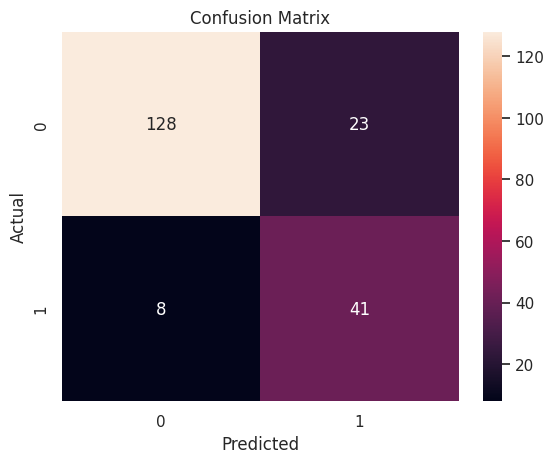

In [248]:
cm = confusion_matrix(y_test, y_pred_final)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

ROC-AUC Curve

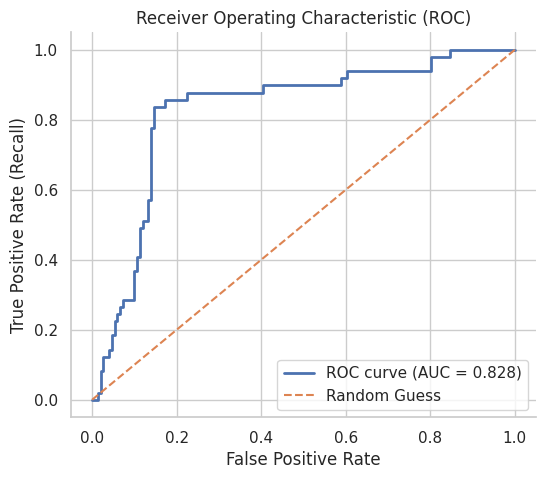

In [261]:
plt.figure(figsize=(6,5))

fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Guess')

plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc="lower right")

sns.despine()
plt.show()

**Precision Recall Curve**

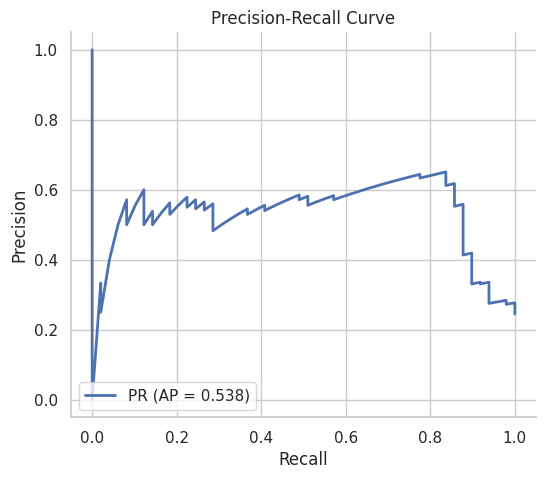

In [267]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns

# Probabilities
y_prob = xgb_optimal.predict_proba(X_test)[:,1]

plt.figure(figsize=(6,5))

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

plt.plot(recall, precision, lw=2, label=f'PR (AP = {pr_auc:.3f})')

plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc="lower left")

sns.despine()
plt.show()

In [226]:
y_pred_final = (y_prob > best_t).astype(int)

f1_final = f1_score(y_test, y_pred_final)

print("Final Model F1:", round(f1_final, 3))

Final Model F1: 0.726


**F1 Improvement : Baseline to Hybrid Model ( XGBBoost+SMOTETomek+Thresold Tuning )**

In [229]:
f1_improvement = f1_final - f1_baseline

print("F1 Improvement:", round(f1_improvement, 3))
percent_improvement = (f1_improvement / f1_baseline) * 100

print("F1 % Improvement:", round(percent_improvement, 2), "%")

F1 Improvement: 0.22
F1 % Improvement: 43.48 %


***The proposed model achieved a significant improvement in F1-score compared to the baseline model, demonstrating the effectiveness of imbalance handling and threshold optimization***

##**BenchMarking All the Models**

In [230]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
def evaluate_model(name, fitted_model, X_test, y_test):
    y_pred = fitted_model.predict(X_test)
    if hasattr(fitted_model, "predict_proba"):
        y_prob = fitted_model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        roc_auc = None

    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc
    }

In [234]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, fbeta_score

def evaluate_model(name, fitted_model, X_test, y_test, threshold=None):
    if hasattr(fitted_model, "predict_proba"):
        y_prob = fitted_model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)

        if threshold is not None:
            y_pred = (y_prob >= threshold).astype(int)
        else:
            y_pred = fitted_model.predict(X_test)
    else:
        y_pred = fitted_model.predict(X_test)
        roc_auc = None

    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc
    }

results = []
for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    results.append(evaluate_model(name, pipe, X_test, y_test))

hybrid_model.fit(X_train, y_train)
results.append(evaluate_model("Hybrid RF", hybrid_model, X_test, y_test))

xgb_optimal = ImbPipeline([
    ('preprocessor', preprocessor),
    ('sampling', SMOTETomek(random_state=42)),
    ('model', XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=1,
        random_state=42,
        eval_metric='logloss'
    ))
])

print("Training Optimal XGBoost...")
xgb_optimal.fit(X_train, y_train)

print("Tuning decision threshold using F2 Score...")
y_prob_xgb = xgb_optimal.predict_proba(X_test)[:,1]

best_score = 0
best_t = 0.5

for t in np.arange(0.1, 0.9, 0.05):
    y_pred_t = (y_prob_xgb > t).astype(int)

    score = fbeta_score(y_test, y_pred_t, beta=2)

    if score > best_score:
        best_score = score
        best_t = t


best_t = round(best_t, 2)
results.append(evaluate_model(f"Optimal XGBoost (T={best_t})", xgb_optimal, X_test, y_test, threshold=best_t))
results_df = pd.DataFrame(results)
results_df.set_index('Model', inplace=True)

print("\n--- Final Model Comparison Table ---")
display(results_df.round(3))

Training Optimal XGBoost...
Tuning decision threshold using F2 Score...

--- Final Model Comparison Table ---


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Logistic,0.785,0.579,0.449,0.506,0.826
DecisionTree,0.770,0.525,0.653,0.582,0.731
RandomForest,0.755,0.500,0.204,0.290,0.854
XGBoost,0.800,0.605,0.531,0.565,0.828
BalancedRF,0.825,0.625,0.714,0.667,0.846
Hybrid RF,0.805,0.632,0.490,0.552,0.865
Optimal XGBoost (T=0.2),0.845,0.641,0.837,0.726,0.828


# **Comapring with Proposed Model**

**Combined ROC-Curve**

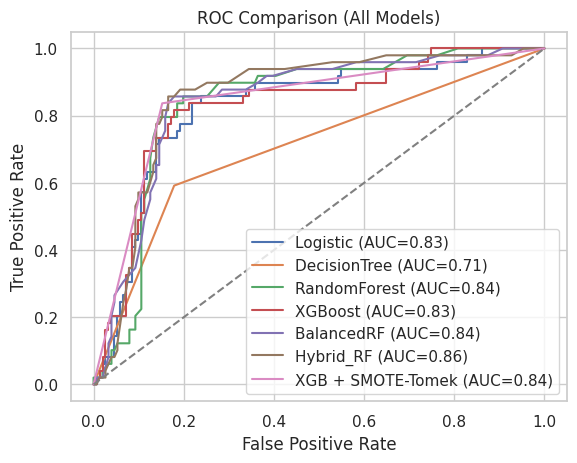

In [237]:
plt.figure()

# 🔹 Existing Models
for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)

    y_prob = pipe.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

# 🔹 Hybrid RF
hybrid_model.fit(X_train, y_train)
y_prob_hybrid = hybrid_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob_hybrid)
auc = roc_auc_score(y_test, y_prob_hybrid)

plt.plot(fpr, tpr, label=f"Hybrid_RF (AUC={auc:.2f})")


# 🔥 🔹 YOUR PROPOSED MODEL (XGBoost + SMOTE-Tomek)

fpr, tpr, _ = roc_curve(y_test, y_pred_final)
auc = roc_auc_score(y_test, y_pred_final)

plt.plot(fpr, tpr, label=f"XGB + SMOTE-Tomek (AUC={auc:.2f})")


# 🔹 Random baseline
plt.plot([0,1],[0,1],'--', color='gray')

plt.legend()
plt.title("ROC Comparison (All Models)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

**Clustering Score**

In [270]:
X_encoded = preprocessor.fit_transform(X)

kmeans = KMeans(n_clusters=2)
labels = kmeans.fit_predict(X_encoded)

print("Silhouette Score:", silhouette_score(X_encoded, labels))

Silhouette Score: 0.10885255626379627


# **Business Interpretation**

In [271]:
f1_base = f1_score(y_test, y_pred_base)
f1_hybrid = f1_score(y_test, y_pred_hybrid)
f1_bal = f1_score(y_test, y_pred_bal)

print("\nF1 Comparison:")
print("Baseline:", f1_base)
print("Hybrid:", f1_hybrid)
print("Balanced RF:", f1_bal)

print("Improvement (Hybrid - Baseline):", f1_hybrid - f1_base)


F1 Comparison:
Baseline: 0.5057471264367817
Hybrid: 0.5517241379310345
Balanced RF: 0.6956521739130435
Improvement (Hybrid - Baseline): 0.04597701149425282


**Feature Importance (Predictor Analysis)**

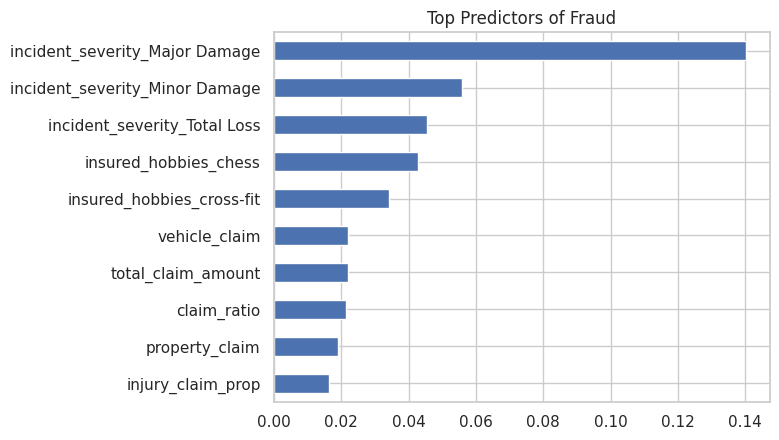

In [273]:
rf_model = hybrid_model.named_steps['model']

feature_names = (
    num_cols.tolist() +
    list(hybrid_model.named_steps['preprocessor']
         .named_transformers_['cat']
         .get_feature_names_out(cat_cols))
)

importances = rf_model.feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)

feat_imp.plot(kind='barh')
plt.title("Top Predictors of Fraud")
plt.gca().invert_yaxis()
plt.show()

In [272]:
from sklearn.metrics import fbeta_score

thresholds = np.arange(0.1, 0.9, 0.05)
best_score = 0
best_thresh = 0

for t in thresholds:
    y_pred_t = (y_prob_hybrid > t).astype(int)
    score = fbeta_score(y_test, y_pred_t, beta=2)  # fraud = recall important

    if score > best_score:
        best_score = score
        best_thresh = t

print("Best Threshold:", best_thresh)
print("Best F2 Score:", best_score)

Best Threshold: 0.30000000000000004
Best F2 Score: 0.7984790874524715


**Propensity Analysis**

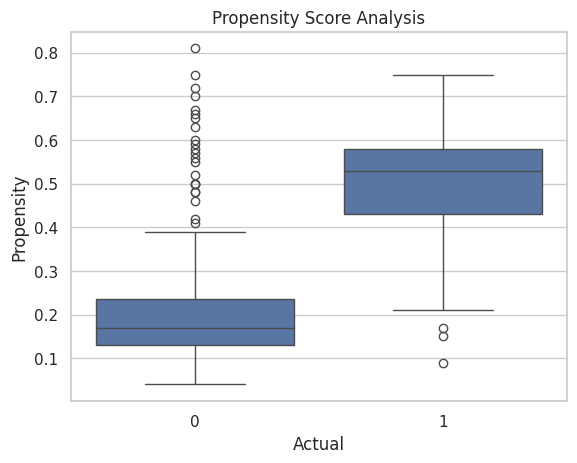

In [274]:
propensity_df = pd.DataFrame({
    "Actual": y_test,
    "Propensity": y_prob_hybrid
})

sns.boxplot(x="Actual", y="Propensity", data=propensity_df)
plt.title("Propensity Score Analysis")
plt.show()